In [1]:
import re
import nltk
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/kaggle/input/imdb-movie-reviews/IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
df.duplicated().sum()

418

In [5]:
positive_reviews = df[df['sentiment'] == 'positive'].sample(n=5000, random_state=42)
negative_reviews = df[df['sentiment'] == 'negative'].sample(n=5000, random_state=42)

df = pd.concat([positive_reviews, negative_reviews]).sample(frac=1.0, random_state=42).reset_index(drop=True)


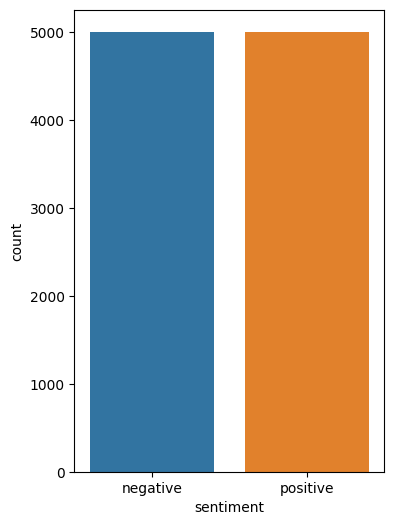

In [6]:
plt.figure(figsize=(4,6))
sns.countplot(data=df,x='sentiment')
plt.show()

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

0

In [9]:
df['review'].head()

0    Starts really well, nice intro and build up fo...
1    Terrific movie: If you did not watch yet, you ...
2    I've seen hundreds of silent movies. Some will...
3    i had been looking for this film for so long b...
4    Good: Engaging cinematic firefights, great pre...
Name: review, dtype: object

In [10]:
def clean_text(text):
    
    text=BeautifulSoup(text,'html.parser').get_text()
    text=re.sub(r"[^A-Za-z0-9\s']","",text)
    text=text.lower()
    return text

cleaned_reviews=df['review'].apply(clean_text)

print(cleaned_reviews.head())

0    starts really well nice intro and build up for...
1    terrific movie if you did not watch yet you mu...
2    i've seen hundreds of silent movies some will ...
3    i had been looking for this film for so long b...
4    good engaging cinematic firefights great prese...
Name: review, dtype: object


In [11]:
import tensorflow as tf
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


2025-08-10 10:12:32.451666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754820752.778931      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754820752.870483      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [12]:
#i figured this out:
 
"""Stopwords → Transformer models like DistilBERT don’t require stopword removal. 
Stopwords can carry context, so removing them can actually hurt performance.""" 

# and also this:
#DistilBERT already uses WordPiece tokenization — words are split into subword units, so related forms share pieces.

'Stopwords → Transformer models like DistilBERT don’t require stopword removal. \nStopwords can carry context, so removing them can actually hurt performance.'

In [13]:

def prepare_bert_data(reviews,sentiments):
    
    labels=LabelEncoder().fit_transform(sentiments)
    
    x_train,x_test,y_train,y_test=train_test_split(reviews,labels, test_size=0.2, stratify=labels,random_state=42)
    
    tokenizer=AutoTokenizer.from_pretrained('distilbert-base-uncased')
    
    train_encodings = tokenizer(x_train, truncation=True, padding='max_length', max_length=250)
    test_encodings = tokenizer(x_test, truncation=True, padding='max_length', max_length=250)
    
    train_dataset=tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train)).shuffle(len(y_train)).batch(32)
    test_dataset=tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test)).batch(32)

    return train_dataset, test_dataset, tokenizer, y_test






In [14]:
from transformers import TFDistilBertForSequenceClassification, create_optimizer
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [15]:
def bert_model(train_dataset):

    steps_per_epoch = tf.data.experimental.cardinality(train_dataset).numpy()
    epochs=2
    num_train_steps=steps_per_epoch*epochs
    
    
    optimizer,_=create_optimizer(
        init_lr=2e-5,
        num_train_steps=num_train_steps,
        num_warmup_steps=int(0.1*num_train_steps)
    )
    
    model=TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    
    model.summary()

    return model
    

In [16]:
def train_history_for_bert(bert_model,train_dataset,test_dataset):
    history=bert_model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=2
    )
    return history

In [17]:
reviews=df['review'].tolist()
sentiments=df['sentiment']



In [18]:
train_dataset,test_dataset,tokenizer,y_test=prepare_bert_data(reviews,sentiments)
model=bert_model(train_dataset)
model_train_history=train_history_for_bert(model,train_dataset,test_dataset)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

I0000 00:00:1754820782.569191      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754820782.570032      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/2


I0000 00:00:1754820810.699556      66 service.cc:148] XLA service 0x7e03925ab8a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754820810.700230      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1754820810.700248      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1754820810.785801      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1754820810.934301      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 [==============================] - 239s 848ms/step - loss: 0.3887 - accuracy: 0.8161 - val_loss: 0.2502 - val_accuracy: 0.9029
Epoch 2/2
250/250 [==============================] - 221s 883ms/step - loss: 0.2011 - accuracy: 0.9247 - val_loss: 0.2427 - val_accuracy: 0.9109


In [19]:
save_path = "/kaggle/working/bert_sentiment_nada"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

('/kaggle/working/bert_sentiment_nada/tokenizer_config.json',
 '/kaggle/working/bert_sentiment_nada/special_tokens_map.json',
 '/kaggle/working/bert_sentiment_nada/vocab.txt',
 '/kaggle/working/bert_sentiment_nada/added_tokens.json',
 '/kaggle/working/bert_sentiment_nada/tokenizer.json')